In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torchmetrics import MeanMetric, AUROC
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
train_data = pd.read_csv('loan_train.csv').drop(columns=["id"])
test_data = pd.read_csv('loan_test.csv').drop(columns=["id"])

In [ ]:
cat_features = train_data.drop(columns=["loan_status"]).select_dtypes("object").columns
num_features = train_data.drop(columns=["loan_status"]).select_dtypes("number").columns

C_MAPS = {
    cat_col:
        {value: encoded_value
            for encoded_value, value in enumerate(train_data[cat_col].unique())}
        for cat_col in cat_features
}

In [ ]:
C_MAPS

{'person_home_ownership': {'MORTGAGE': 0, 'RENT': 1, 'OWN': 2, 'OTHER': 3},
 'loan_intent': {'EDUCATION': 0,
  'HOMEIMPROVEMENT': 1,
  'MEDICAL': 2,
  'DEBTCONSOLIDATION': 3,
  'VENTURE': 4,
  'PERSONAL': 5},
 'loan_grade': {'A': 0, 'D': 1, 'B': 2, 'C': 3, 'F': 4, 'E': 5, 'G': 6},
 'cb_person_default_on_file': {'N': 0, 'Y': 1}}

In [ ]:
class LoanDataset(Dataset):
    def __init__(self, data: pd.DataFrame, target: pd.Series):
        self.data = data
        self.target = target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        target_item = self.target.iloc[idx]
        out = {"num_features": {}, "cat_features": {}}
        for col in item.index:
            if col in cat_features:
                out["cat_features"][col] = torch.tensor(C_MAPS[col][item[col]], dtype=torch.long)
            else:
                out["num_features"][col] = torch.tensor(item[col], dtype=torch.float)
        out["target"] = torch.tensor(target_item, dtype=torch.float)
        return out

In [ ]:
class LoanModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LoanModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size * 4)
        self.fc3 = nn.Linear(hidden_size * 4, hidden_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [ ]:
train_data.drop(columns=["loan_status", *cat_features])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
0,21,102000,5.0,10000.0,7.51,0.10,4.0
1,23,49000,1.0,5000.0,13.17,0.10,4.0
2,23,30000,1.0,10000.0,11.99,0.33,4.0
3,32,95000,9.0,15000.0,12.84,0.16,5.0
4,31,32000,3.0,1200.0,7.68,0.04,10.0
...,...,...,...,...,...,...,...
34557,23,60000,1.0,4000.0,10.99,0.07,4.0
34558,26,39996,9.0,5000.0,14.82,0.13,2.0
34559,30,75000,7.0,12000.0,7.88,0.16,8.0
34560,24,36000,8.0,9000.0,7.51,0.25,2.0


In [ ]:
num_features

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(train_data.drop(columns=["loan_status", *cat_features], axis=1)), columns=num_features)
Test_scaled = pd.DataFrame(scaler.transform(test_data.drop(columns=["loan_status", *cat_features], axis=1)), columns=num_features)

X_scaled = pd.concat([X_scaled, train_data[cat_features]], axis=1)
Test_scaled = pd.concat([Test_scaled, test_data[cat_features]], axis=1)

x_train, x_val, y_train, y_val = train_test_split(X_scaled, train_data["loan_status"], test_size=0.2, stratify=train_data["loan_status"])

train_dataset = LoanDataset(x_train, y_train)
val_dataset = LoanDataset(x_val, y_val)
test_dataset = LoanDataset(Test_scaled, test_data["loan_status"])

In [ ]:
def train(model: nn.Module, train_dataset: Dataset, eval_dataset: Dataset, config : dict):

    seed = 52
    device = "cuda" if torch.cuda.is_available() else "cpu"
    n_epochs = config["num_epochs"]
    lr = config["lr"]
    weight_decay = config["decay"] if "decay" in config else 0.0
    batch_size = config["batch_size"]

    torch.random.manual_seed(seed)

    model = model.to(device)
    loss_bce = torch.nn.BCEWithLogitsLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_dl = DataLoader(train_dataset, batch_size=batch_size, num_workers=4, pin_memory=True)
    eval_dl = DataLoader(eval_dataset, batch_size=batch_size, num_workers=4, pin_memory=True)

    history = {"train_losses": [], "train_auc": [], "val_losses": [], "val_auc": []}
    best_eval_loss = float('inf')

    for i_epoch in tqdm(range(n_epochs)):
        train_loss = MeanMetric().to(device)
        train_rocauc = AUROC(task='binary').to(device)
        for i, batch in enumerate(train_dl):
            num_features, cat_features, target = batch["num_features"], batch["cat_features"], batch["target"].to(device)

            for col in num_features:
                num_features[col] = num_features[col].to(device)

            for col in cat_features:
                cat_features[col] = cat_features[col].to(device)

            result = model(num_features=num_features, cat_features=cat_features)


            loss_value = loss_bce(result, target)
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss.update(loss_value)
            train_rocauc.update(torch.sigmoid(result), target)

        train_loss = train_loss.compute().item()
        train_rocauc = train_rocauc.compute().item()

        history["train_losses"].append(train_loss)
        history["train_auc"].append(train_rocauc)

        eval_loss = MeanMetric().to(device)
        eval_rocauc = AUROC(task='binary').to(device)


        model.eval()
        with torch.no_grad():
            for i_eval, batch_eval in enumerate(eval_dl):
                num_features, cat_features, target = batch_eval["num_features"], batch_eval["cat_features"], batch_eval["target"].to(device)

                for col in num_features:
                    num_features[col] = num_features[col].to(device)

                for col in cat_features:
                    cat_features[col] = cat_features[col].to(device)

                result_eval = model(num_features=num_features, cat_features=cat_features)


                eval_loss_value = loss_bce(result_eval, target)

                eval_loss.update(eval_loss_value)
                eval_rocauc.update(torch.sigmoid(result_eval),target)
        model.train()

        eval_loss = eval_loss.compute().item()
        eval_rocauc = eval_rocauc.compute().item()

        history["val_losses"].append(eval_loss)
        history["val_auc"].append(eval_rocauc)

        if eval_loss < best_eval_loss:
            torch.save(model.state_dict(), "model.pt")

    return history

In [ ]:
config = {"num_epochs": 10, "lr": 0.01, "batch_size": 32}

In [ ]:
def test(model: nn.Module, test_dataset: Dataset, config: dict):
    model.eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    test_dl = DataLoader(test_dataset, batch_size=config["batch_size"])

    loss_bce = torch.nn.BCEWithLogitsLoss()
    test_loss = MeanMetric().to(device)
    test_rocauc = AUROC(task='binary').to(device)

    model.eval()
    with torch.no_grad():
        for i_eval, batch in enumerate(test_dl):
            num_features, cat_features, target = batch["num_features"], batch["cat_features"], batch["target"].to(device)

            for col in num_features:
                num_features[col] = num_features[col].to(device)

            for col in cat_features:
                cat_features[col] = cat_features[col].to(device)

            result_eval = model(num_features=num_features, cat_features=cat_features)
            loss_value = loss_bce(result_eval, target)

            test_loss.update(loss_value)
            test_rocauc.update(torch.sigmoid(result_eval),target)

    test_loss = test_loss.compute().item()
    test_rocauc = test_rocauc.compute().item()

    return test_loss, test_rocauc

In [ ]:
C_MAPS

{'person_home_ownership': {'MORTGAGE': 0, 'RENT': 1, 'OWN': 2, 'OTHER': 3},
 'loan_intent': {'EDUCATION': 0,
  'HOMEIMPROVEMENT': 1,
  'MEDICAL': 2,
  'DEBTCONSOLIDATION': 3,
  'VENTURE': 4,
  'PERSONAL': 5,
  'H': 6},
 'loan_grade': {'A': 0,
  'D': 1,
  'B': 2,
  'C': 3,
  'F': 4,
  'E': 5,
  'G': 6,
  nan: 7},
 'cb_person_default_on_file': {'N': 0, 'Y': 1, nan: 2}}

# Первый эксперимент

In [ ]:
class SimpleLoanModel(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.emb1 = nn.Embedding(4, hidden_size//8)
        self.emb2 = nn.Embedding(6, hidden_size//8)
        self.emb3 = nn.Embedding(7, hidden_size//8)
        self.emb4 = nn.Embedding(2, hidden_size//8)

        self.linear_in = nn.Linear(7, hidden_size//2)

        self.linear1 = nn.Linear(hidden_size, hidden_size * 4)
        self.linear2 = nn.Linear(hidden_size * 4, hidden_size)

        self.linear_out = nn.Linear(hidden_size, 1)

        self.relu = nn.ReLU()


    def forward(self, num_features: Tensor, cat_features: Tensor):
        x_1 = self.emb1(cat_features["person_home_ownership"])
        x_2 = self.emb2(cat_features["loan_intent"])
        x_3 = self.emb3(cat_features["loan_grade"])
        x_4 = self.emb4(cat_features["cb_person_default_on_file"])


        x_num = self.linear_in(torch.stack([feature for feature in num_features.values()], dim=-1))

        x = torch.cat([x_1, x_2, x_3, x_4, x_num], axis=-1)

        x = self.relu(self.linear1(x))
        x = self.linear2(x)
        x = self.linear_out(x)
        return x.squeeze(-1)

In [ ]:
config = {
    "num_epochs": 30,
    "lr": 0.01,
    "hidden_size": 32,
    "batch_size": 32
}

model = SimpleLoanModel(config["hidden_size"])

history = train(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    config=config,
)

100%|██████████| 30/30 [16:39<00:00, 33.32s/it]


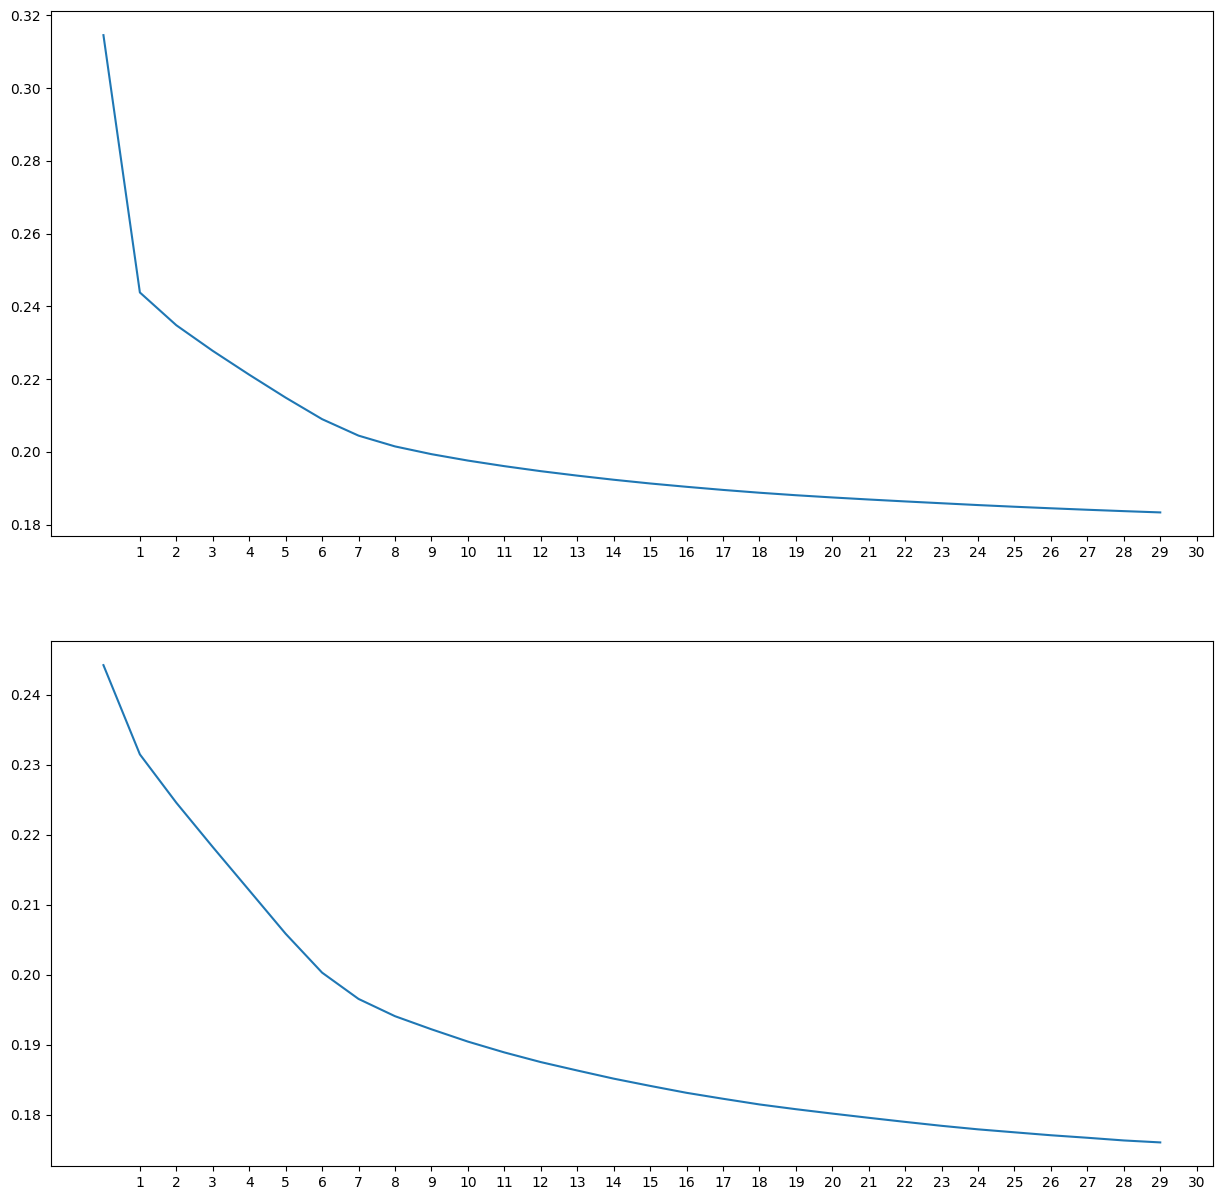

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history["train_losses"])
axis[0].set_xticks(range(1, len(history["train_losses"])+1))

axis[1].plot(history["val_losses"])
axis[1].set_xticks(range(1, len(history["val_losses"])+1))

plt.show()

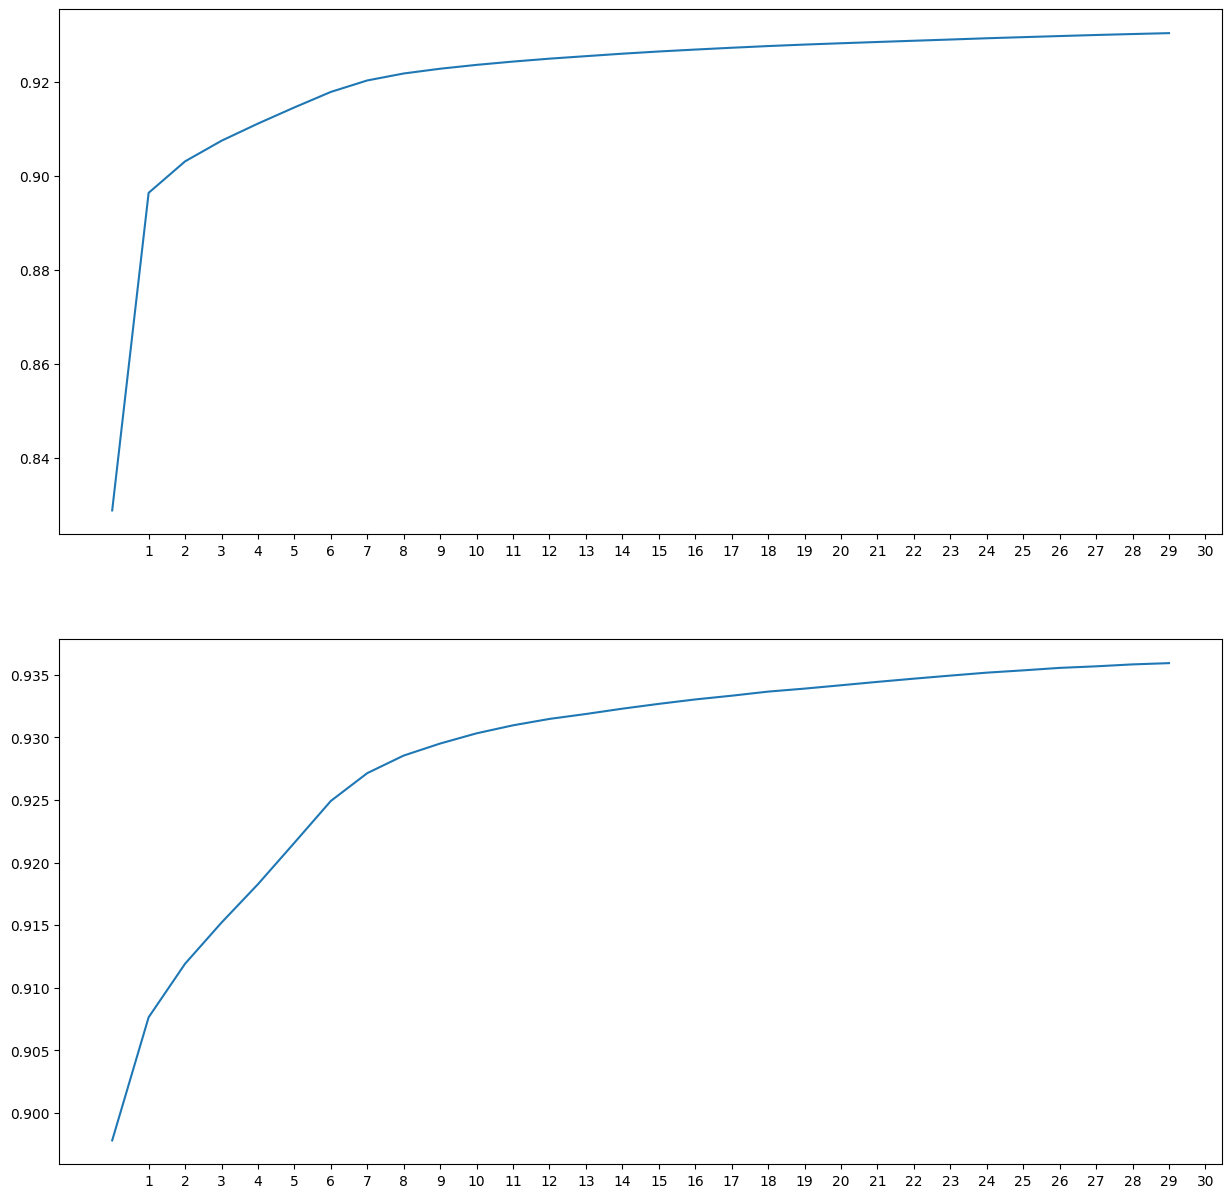

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history["train_auc"])
axis[0].set_xticks(range(1, len(history["train_auc"])+1))

axis[1].plot(history["val_auc"])
axis[1].set_xticks(range(1, len(history["val_auc"])+1))

plt.show()

In [ ]:
min_value = float("inf")
epoch = -1

min_val_loss = min(history["val_losses"])

if min_val_loss < min_value:
    min_value = min_val_loss
    epoch = history["val_losses"].index(min_val_loss)

min_value, epoch

(0.17606748640537262, 29)

In [ ]:
print(num_features)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')


In [ ]:
loss, auc = test(
    model=model,
    test_dataset=test_dataset,
    config=config)

loss, auc

(0.18260781466960907, 0.9312570095062256)

# Второй эксперимент

In [ ]:
class LoanModelBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.linear1 = nn.Linear(hidden_size, hidden_size*4)
        self.linear2 = nn.Linear(hidden_size*4, hidden_size)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.linear2(x)

        return x

class LoanModelExtra(nn.Module):
    def __init__(self, hidden_size: int, num_blocks: int = 1):
        super().__init__()
        self.emb1 = nn.Embedding(4, hidden_size//8)
        self.emb2 = nn.Embedding(6, hidden_size//8)
        self.emb3 = nn.Embedding(7, hidden_size//8)
        self.emb4 = nn.Embedding(2, hidden_size//8)

        self.numeric_linear = nn.Linear(7, hidden_size//2)

        self.linear_blocks = nn.Sequential(*[LoanModelBlock(hidden_size) for _ in range(num_blocks)])

        self.linear_out = nn.Linear(hidden_size, 1)

    def forward(self, num_features: Tensor, cat_features: Tensor):
        x_1 = self.emb1(cat_features["person_home_ownership"])
        x_2 = self.emb2(cat_features["loan_intent"])
        x_3 = self.emb3(cat_features["loan_grade"])
        x_4 = self.emb4(cat_features["cb_person_default_on_file"])


        x_num = self.numeric_linear(torch.stack([feature for feature in num_features.values()], dim=-1))

        x = torch.cat([x_1, x_2, x_3, x_4, x_num], axis=-1)


        for block in self.linear_blocks:
            x = block(x)

        result = self.linear_out(x)

        return result.squeeze(-1)

In [ ]:
config = {
    "num_epochs": 30,
    "lr": 0.01,
    "hidden_size": 128,
    "batch_size": 64,
    "num_blocks": 3
}

model = LoanModelExtra(config["hidden_size"], config["num_blocks"])

history = train(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    config=config,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 30/30 [14:06<00:00, 28.23s/it]


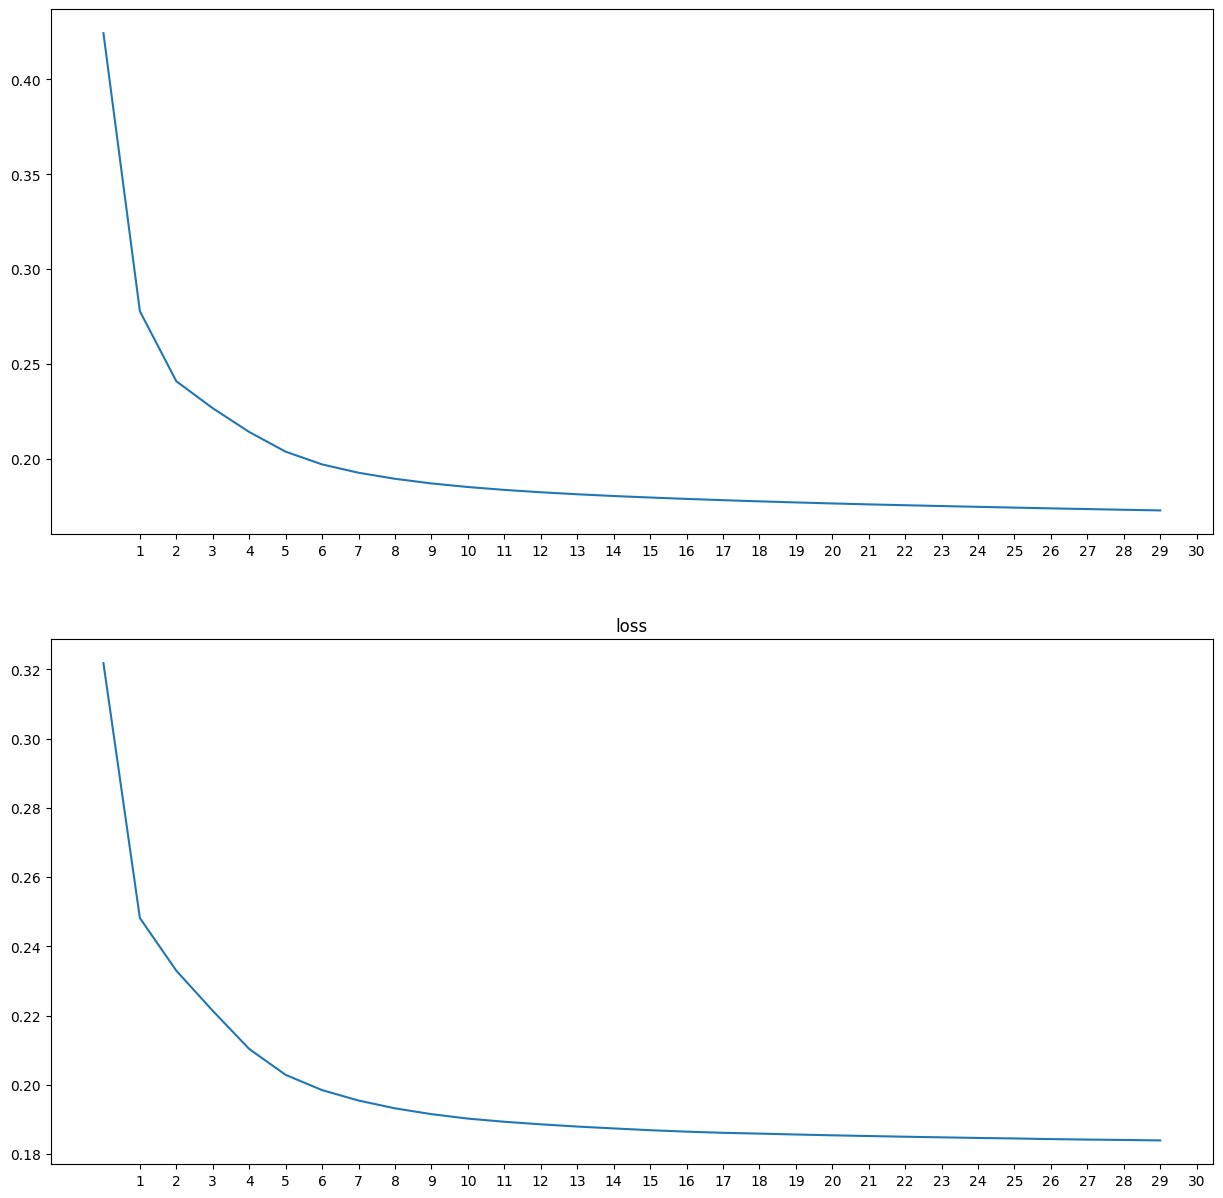

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history["train_losses"])
axis[0].set_xticks(range(1, len(history["train_losses"])+1))

axis[1].plot(history["val_losses"])
axis[1].set_xticks(range(1, len(history["val_losses"])+1))

plt.title("loss")
plt.show()

In [ ]:
min_value = float("inf")
epoch = -1

min_val_loss = min(history["val_losses"])

if min_val_loss < min_value:
    min_value = min_val_loss
    epoch = history["val_losses"].index(min_val_loss)

min_value, epoch

(0.18394699692726135, 29)

In [ ]:
model.load_state_dict(torch.load("model.pt"))

<All keys matched successfully>

In [ ]:
loss, auc = test(
    model=model,
    test_dataset=test_dataset,
    config=config)

loss, auc

(0.17593024671077728, 0.9318679571151733)

# Третий эксперимент

In [ ]:
import torch
from torch import nn, Tensor

class LoanModelBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.linear1 = nn.Linear(hidden_size, hidden_size*4)
        self.linear2 = nn.Linear(hidden_size*4, hidden_size)


        self.bn = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        to_skip = x
        x = self.bn(x)
        x = self.relu(self.linear1(x))
        x = self.linear2(x)

        return x + to_skip

class LoanModelExtraWithBn(nn.Module):
    def __init__(self, hidden_size: int, num_blocks: int = 1):
        super().__init__()
        self.emb1 = nn.Embedding(4, hidden_size//8)
        self.emb2 = nn.Embedding(6, hidden_size//8)
        self.emb3 = nn.Embedding(7, hidden_size//8)
        self.emb4 = nn.Embedding(2, hidden_size//8)

        self.numeric_linear = nn.Linear(7, hidden_size//2)

        layers = []

        for _ in range(num_blocks):
            layers.append(LoanModelBlock(hidden_size))

        self.linear_blocks = nn.Sequential(*layers)

        self.linear_out = nn.Linear(hidden_size, 1)

    def forward(self, num_features: Tensor, cat_features: Tensor) -> Tensor:
        x_1 = self.emb1(cat_features["person_home_ownership"])
        x_2 = self.emb2(cat_features["loan_intent"])
        x_3 = self.emb3(cat_features["loan_grade"])
        x_4 = self.emb4(cat_features["cb_person_default_on_file"])


        x_num = self.numeric_linear(torch.stack([feature for feature in num_features.values()], dim=-1))

        x = torch.cat([x_1, x_2, x_3, x_4, x_num], axis=-1)


        x = self.linear_blocks(x)

        result = self.linear_out(x)

        return result.view(-1)

In [ ]:
config = {
    "num_epochs": 30,
    "lr": 0.01,
    "hidden_size": 128,
    "batch_size": 128,
    "num_blocks": 3
}

model = LoanModelExtraWithBn(config["hidden_size"], config["num_blocks"])

In [ ]:
history = train(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    config=config,
)

100%|██████████| 30/30 [12:27<00:00, 24.91s/it]


In [ ]:
min_value = float("inf")
epoch = -1

min_val_loss = min(history["val_losses"])

if min_val_loss < min_value:
    min_value = min_val_loss
    epoch = history["val_losses"].index(min_val_loss)

min_value, epoch

(0.19187337160110474, 16)

In [ ]:
model.load_state_dict(torch.load("model.pt"))

loss, auc = test(
    model=model,
    test_dataset=test_dataset,
    config=config)

loss, auc

(0.18671829998493195, 0.9224151968955994)

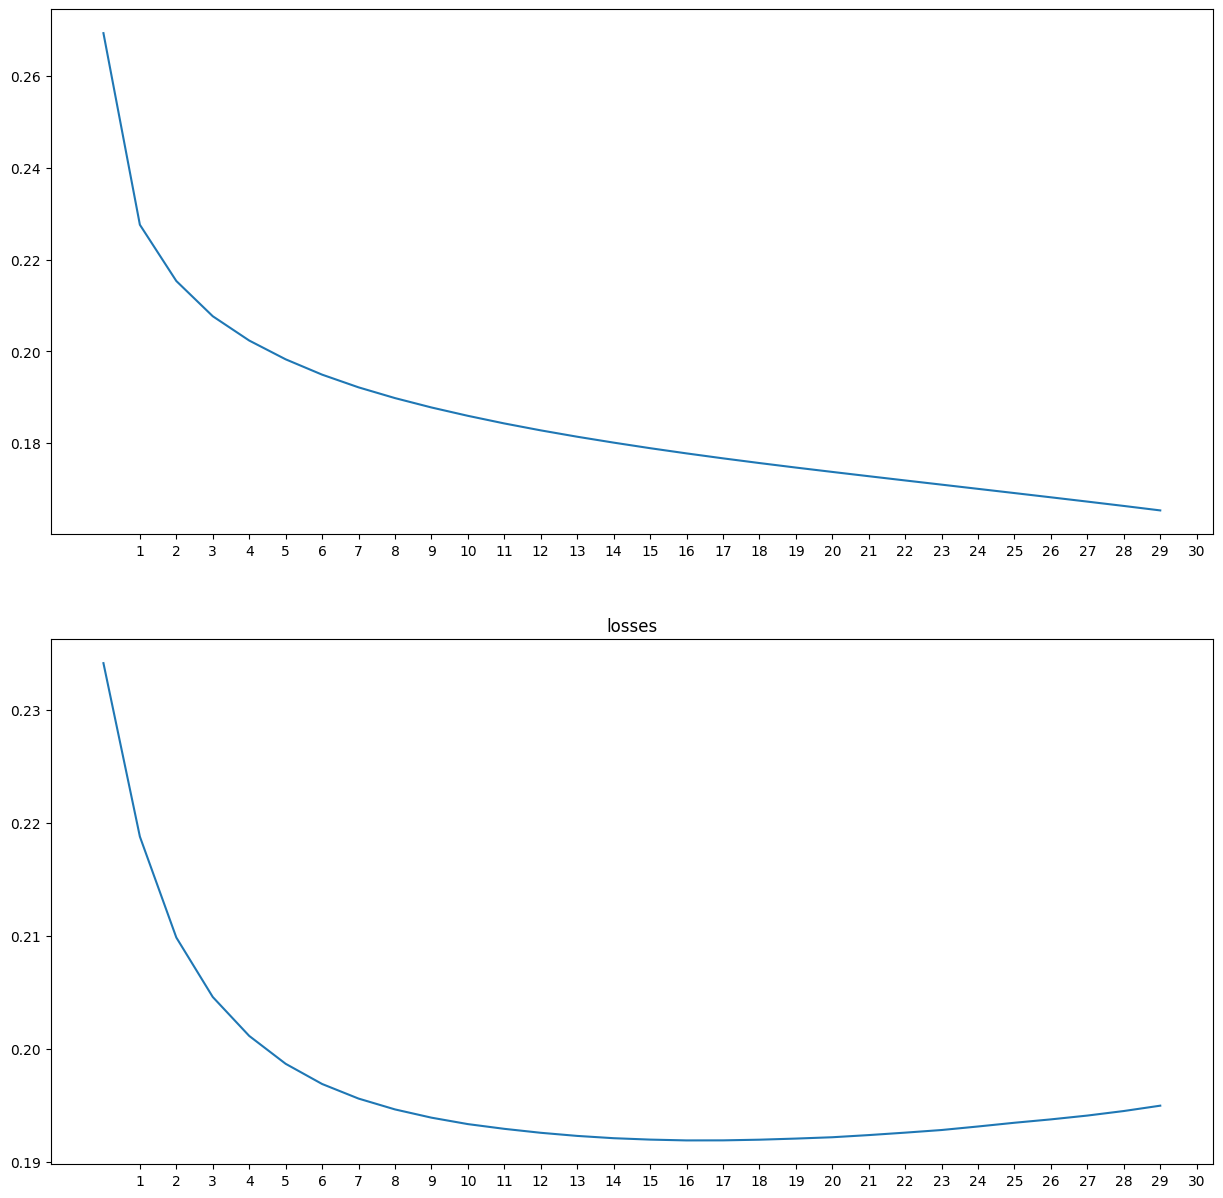

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history["train_losses"])
axis[0].set_xticks(range(1, len(history["train_losses"])+1))

axis[1].plot(history["val_losses"])
axis[1].set_xticks(range(1, len(history["val_losses"])+1))

plt.title("losses")
plt.show()

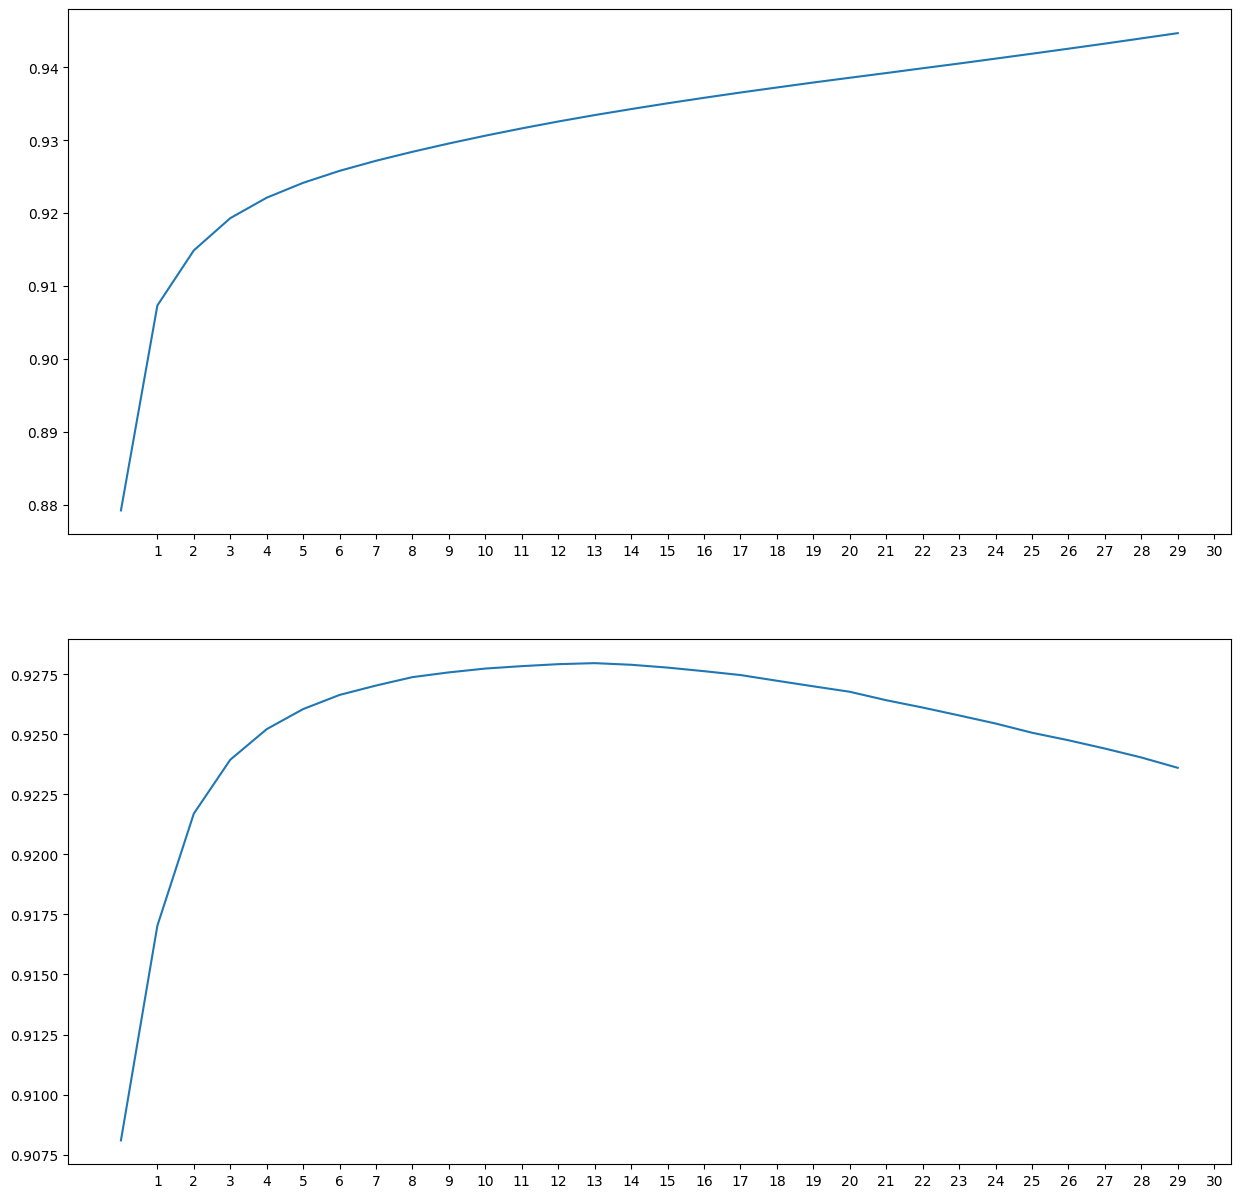

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history["train_auc"])
axis[0].set_xticks(range(1, len(history["train_auc"])+1))

axis[1].plot(history["val_auc"])
axis[1].set_xticks(range(1, len(history["train_auc"])+1))

plt.show("roc-auc")
plt.show()

# Четвёртый эксперимент

In [ ]:
import torch
from torch import nn, Tensor

class LoanModelBlock(nn.Module):
    def __init__(self, hidden_size, p):
        super().__init__()
        self.linear1 = nn.Linear(hidden_size, hidden_size*4)
        self.linear2 = nn.Linear(hidden_size*4, hidden_size)

        self.bn = nn.BatchNorm1d(hidden_size)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        to_skip = x
        x = self.bn(x)
        x = self.relu(self.linear1(x))
        x = self.dropout(self.relu(self.linear2(x)))

        return x + to_skip

class LoanModelExtraWithDropout(nn.Module):
    def __init__(self, hidden_size: int, num_blocks: int = 1, p: int = 0.5):
        super().__init__()
        self.emb1 = nn.Embedding(4, hidden_size)
        self.emb2 = nn.Embedding(6, hidden_size)
        self.emb3 = nn.Embedding(7, hidden_size)
        self.emb4 = nn.Embedding(2, hidden_size)

        self.numeric_linear = nn.Linear(7, hidden_size)

        layers = []

        for _ in range(num_blocks):
            layers.append(LoanModelBlock(hidden_size, p))

        self.linear_blocks = nn.Sequential(*layers)

        self.linear_out = nn.Linear(hidden_size, 1)

    def forward(self, num_features: Tensor, cat_features: Tensor) -> Tensor:
        x_1 = self.emb1(cat_features["person_home_ownership"])
        x_2 = self.emb2(cat_features["loan_intent"])
        x_3 = self.emb3(cat_features["loan_grade"])
        x_4 = self.emb4(cat_features["cb_person_default_on_file"])


        x_num = self.numeric_linear(torch.stack([feature for feature in num_features.values()], dim=-1))

        x = x_1 + x_2 + x_3 + x_4 + x_num

        x = self.linear_blocks(x)

        result = self.linear_out(x)

        return result.view(-1)

In [ ]:
configs = []
ps = [0.01, 0.1, 0.2, 0.5, 0.9]
for p in ps:
    configs.append({
        "num_epochs": 30,
        "lr": 0.01,
        "hidden_size": 128,
        "batch_size": 128,
        "num_blocks": 3,
        "p": p
    })

In [ ]:
history = []
metrics = []

for config in configs:
    model = LoanModelExtraWithDropout(config["hidden_size"], config["num_blocks"], config["p"])

    history_tmp = train(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    config=config,
    )
    history.append(history_tmp)

    model.load_state_dict(torch.load("model.pt"))

    test_loss, test_auc = test(
        model=model,
        test_dataset=test_dataset,
        config=config)

    metrics.append((test_loss, test_auc))

100%|██████████| 30/30 [13:02<00:00, 26.09s/it]


In [ ]:
min_value = float("inf")
p = -1
epoch = -1
idx = - 1

for i, losses in enumerate(history):
    min_val_loss = min(losses["val_losses"])
    print(min_val_loss, ps[i], metrics[i])
    if min_val_loss < min_value:
        min_value = min_val_loss
        p = ps[i]
        epoch = losses["val_losses"].index(min_val_loss)
        idx = i

min_value, p, epoch

0.19306614995002747 0.01 (0.18394966423511505, 0.9306672811508179)
0.19416965544223785 0.1 (0.18483251333236694, 0.9304984211921692)
0.1942499727010727 0.2 (0.184606671333313, 0.9307466149330139)
0.19490276277065277 0.5 (0.18494044244289398, 0.9315177798271179)
0.2032499611377716 0.9 (0.19334501028060913, 0.9288762807846069)


(0.19306614995002747, 0.01, 29)

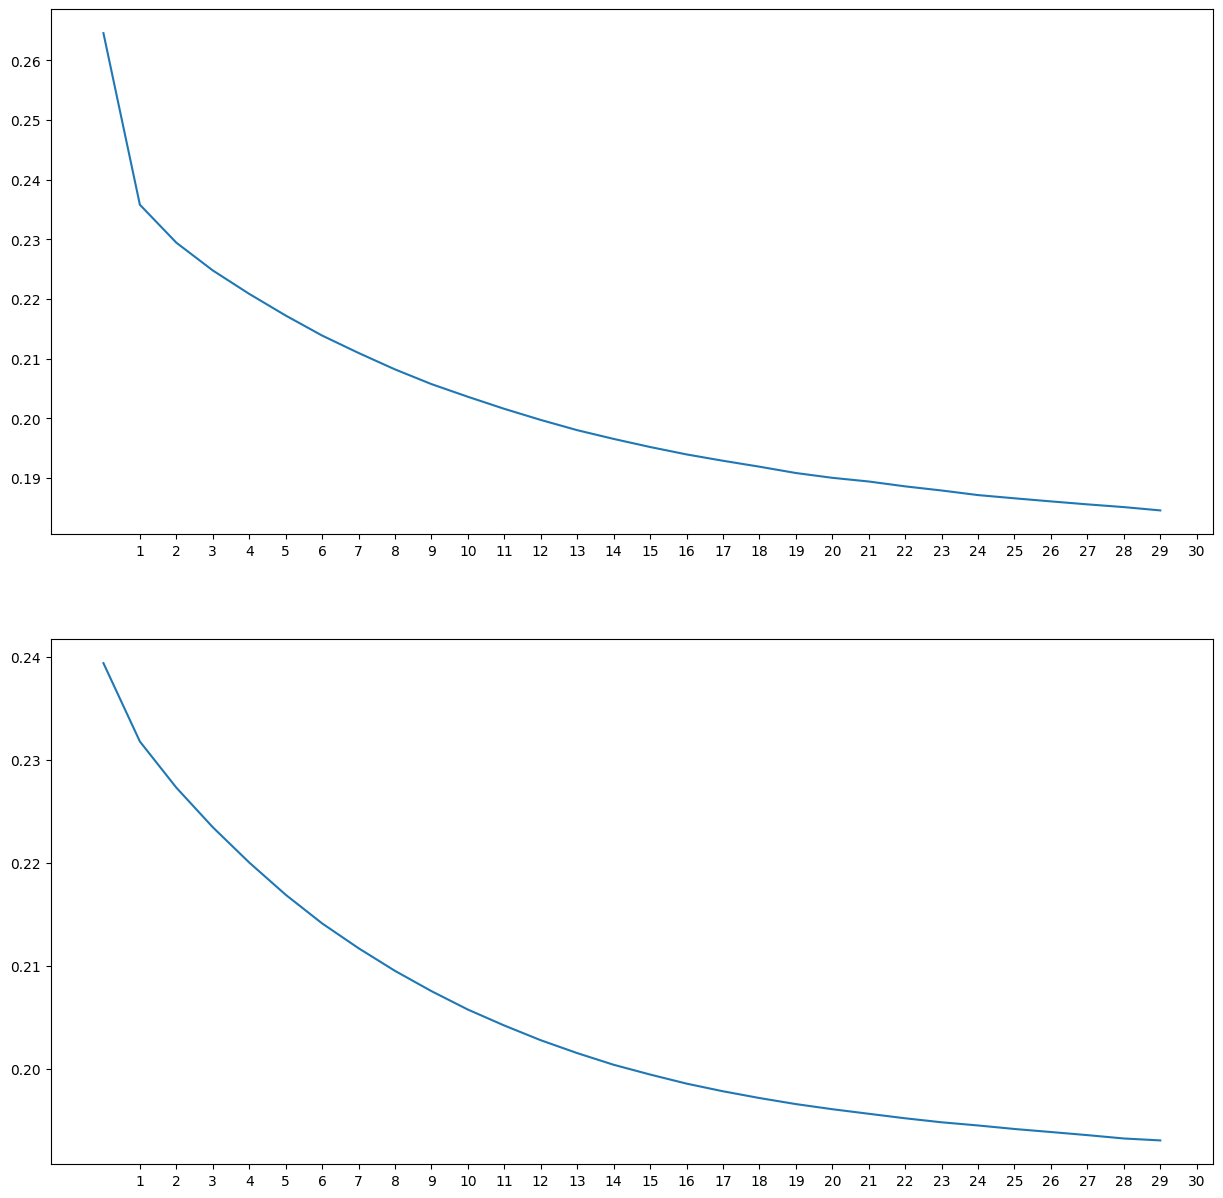

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history[idx]["train_losses"])
axis[0].set_xticks(range(1, len(history[idx]["train_losses"])+1))

axis[1].plot(history[idx]["val_losses"])
axis[1].set_xticks(range(1, len(history[idx]["val_losses"])+1))

plt.show()

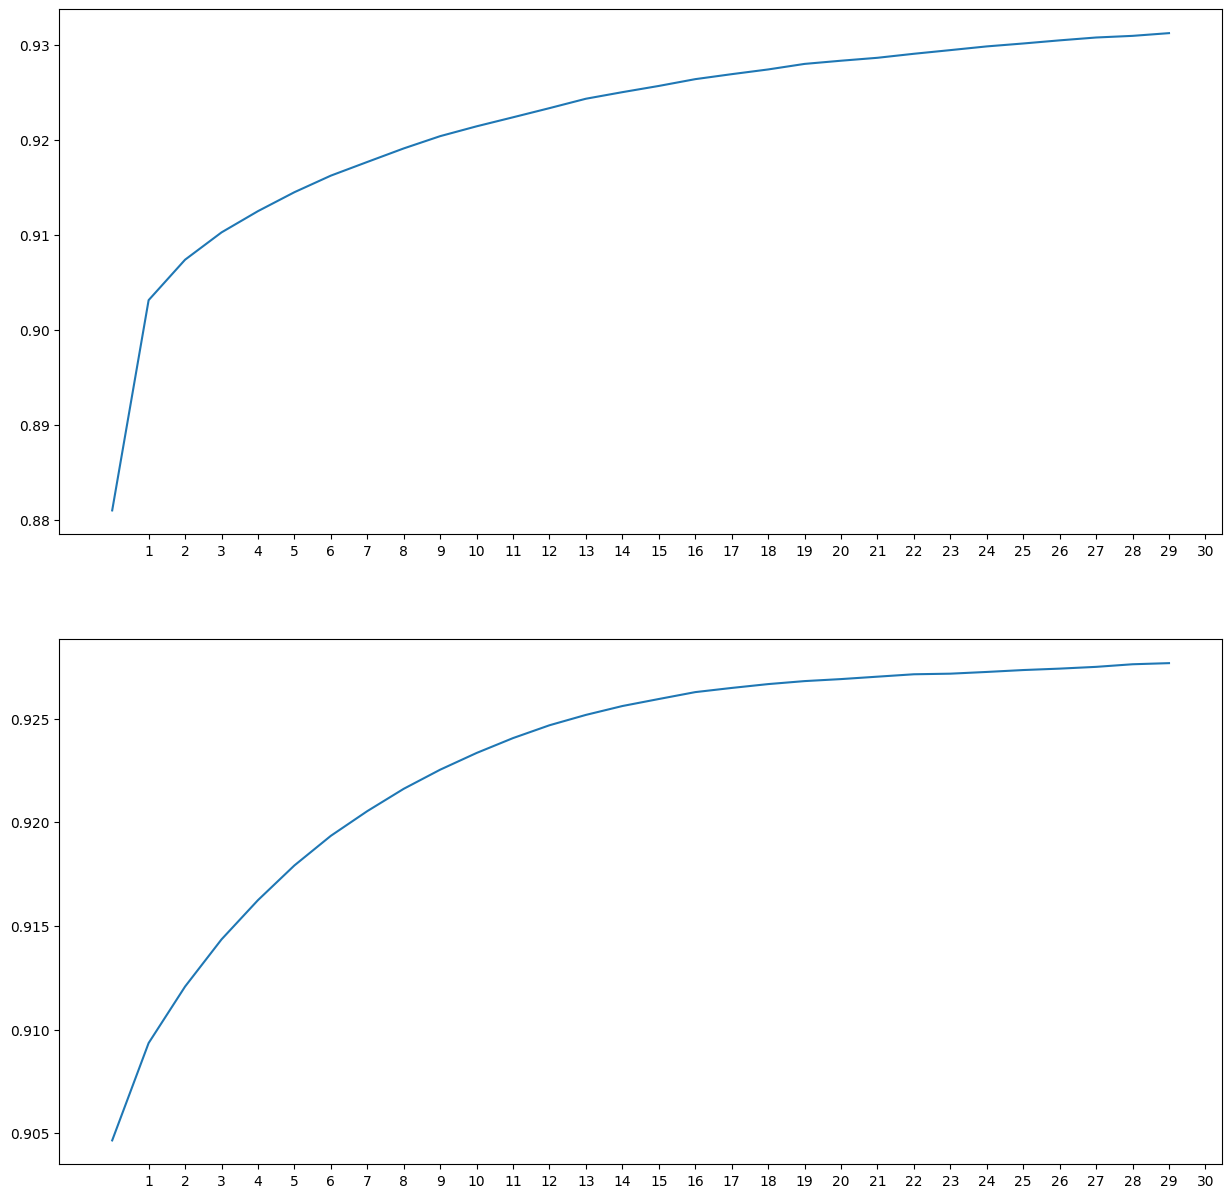

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history[idx]["train_auc"])
axis[0].set_xticks(range(1, len(history[idx]["train_auc"])+1))

axis[1].plot(history[idx]["val_auc"])
axis[1].set_xticks(range(1, len(history[idx]["val_auc"])+1))

plt.show()

# Пятый эксперимент

In [ ]:
configs = []

lrs = [0.01, 0.05, 0.1]
decays = [0.1, 0.01, 0.001]

for lr in lrs:
    for decay in decays:
        configs.append({
            "num_epochs": 50,
            "lr": lr,
            "hidden_size": 128,
            "batch_size": 64,
            "num_blocks": 3,
            "p": 0.1,
            "decay": decay
        })

In [ ]:
history = []
metrics = []

for config in configs:
    model = LoanModelExtraWithDropout(config["hidden_size"], config["num_blocks"], config["p"])

    history_tmp = train(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    config=config
    )
    history.append((history_tmp, config["lr"], config["decay"]))

    model.load_state_dict(torch.load("model.pt"))

    loss, auc = test(
        model=model,
        test_dataset=test_dataset,
        config=config)

    metrics.append((loss, auc))

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 50/50 [15:39<00:00, 18.79s/it]


In [ ]:
min_value = float("inf")
p = -1
decay = -1
lr = - 1
epoch = -1
idx = -1

for i, losses in enumerate(history):
    min_val_loss = min(losses[0]["val_losses"])

    print(min_val_loss, losses[2], losses[1], metrics[i])
    if min_val_loss < min_value:
        min_value = min_val_loss
        epoch = losses[0]["val_losses"].index(min_val_loss)
        decay = losses[2]
        lr = losses[1]
        idx = i

min_value, epoch, decay, lr

0.2569635212421417 0.1 0.01 (0.30279994010925293, 0.8892812728881836)
0.21590159833431244 0.01 0.01 (0.2102404683828354, 0.9225264191627502)
0.18475328385829926 0.001 0.01 (0.18051551282405853, 0.9306546449661255)
0.30167436599731445 0.1 0.05 (0.30349913239479065, 0.8887134790420532)
0.21673688292503357 0.01 0.05 (0.21173572540283203, 0.9207603931427002)
0.18121950328350067 0.001 0.05 (0.178078755736351, 0.932024359703064)
0.3056824505329132 0.1 0.1 (0.30468958616256714, 0.8885358572006226)
0.22208447754383087 0.01 0.1 (0.21858632564544678, 0.9182286262512207)
0.18260261416435242 0.001 0.1 (0.17993438243865967, 0.9315035343170166)


(0.18121950328350067, 48, 0.001, 0.05)

In [ ]:
figure, axis = plt.subplots(2, 1, figsize=(15, 15))
axis[0].plot(history[idx]["train_auc"])
axis[0].set_xticks(range(1, len(history[idx]["train_auc"])+1))

axis[1].plot(history[idx]["val_auc"])
axis[1].set_xticks(range(1, len(history[idx]["val_auc"])+1))

plt.show()